# Sales Data Analysis and Visualization

## CodeAlpha Data Analytics Internship

### Tasks Completed
- Task 2: Exploratory Data Analysis (EDA)
- Task 3: Data Visualization
- Task 4: Sentiment Analysis

**Tools Used:** Python, Pandas, Matplotlib, Seaborn, VADER Sentiment Analysis

# Introduction

This project was completed as part of the CodeAlpha Data Analytics Internship.

The project focuses on analysing sales data, identifying useful patterns and insights, creating visualizations, and performing sentiment analysis on customer reviews.

The analysis was performed using Python and libraries such as Pandas, Matplotlib, Seaborn, and VADER Sentiment Analysis.

In [ ]:
import pandas as pd

data = {
    "Product": ["Laptop", "Phone", "Tablet", "Laptop", "Phone", "Tablet", "Laptop", "Phone", "Tablet", "Laptop"],
    "Category": ["Electronics", "Electronics", "Electronics", "Electronics", "Electronics",
                 "Electronics", "Electronics", "Electronics", "Electronics", "Electronics"],
    "Region": ["North", "South", "East", "West", "North", "South", "East", "West", "North", "South"],
    "Sales": [75000, 52000, 35000, 68000, 48000, 32000, 82000, 55000, 39000, 71000],
    "Quantity": [10, 15, 12, 9, 14, 11, 13, 16, 10, 8],
    "Profit": [12000, 8500, 5000, 10500, 7200, 4500, 13500, 9000, 5800, 11000]
}

df = pd.DataFrame(data)



In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
import os
import shutil

drive_folder = "/content/drive/MyDrive/Colab Notebooks/visualizations"
os.makedirs(drive_folder, exist_ok=True)

for file in os.listdir("visualizations"):
    shutil.copy2(
        os.path.join("visualizations", file),
        os.path.join(drive_folder, file)
    )

print("All charts copied successfully!")
print(os.listdir(drive_folder))

All charts copied successfully!
['sales_by_product.png', 'sales_by_region.png', 'Sentiment Analysis.png', 'profit_by_region.png', 'profit_by_product.png', 'sales_vs_profit_by_product.png']


# Task 2 — Exploratory Data Analysis (EDA)

In this task, the sales dataset is examined to understand its structure, data quality, product performance, regional performance, and overall business performance.

In [ ]:
df.head()

,Product,Category,Region,Sales,Quantity,Profit
0,Laptop,Electronics,North,75000,10,12000
1,Phone,Electronics,South,52000,15,8500
2,Tablet,Electronics,East,35000,12,5000
3,Laptop,Electronics,West,68000,9,10500
4,Phone,Electronics,North,48000,14,7200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Product   10 non-null     object
 1   Category  10 non-null     object
 2   Region    10 non-null     object
 3   Sales     10 non-null     int64 
 4   Quantity  10 non-null     int64 
 5   Profit    10 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes


In [ ]:
df.describe()

,Sales,Quantity,Profit
count,10.000000,10.00000,10.000000
mean,55700.000000,11.80000,8700.000000
std,17613.441837,2.65832,3065.579517
min,32000.000000,8.00000,4500.000000
25%,41250.000000,10.00000,6150.000000
50%,53500.000000,11.50000,8750.000000
75%,70250.000000,13.75000,10875.000000
max,82000.000000,16.00000,13500.000000


In [ ]:
df.isnull().sum()

,0
Product,0
Category,0
Region,0
Sales,0
Quantity,0
Profit,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

,Sales
Product,
Laptop,296000
Phone,155000
Tablet,106000


In [ ]:
df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

,Profit
Product,
Laptop,47000
Phone,24700
Tablet,15300


In [ ]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

,Sales
Region,
North,162000
South,155000
West,123000
East,117000


In [ ]:
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

,Profit
Region,
North,25000
South,24000
West,19500
East,18500


In [ ]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

Total Sales: 557000
Total Profit: 87000


In [ ]:
df.loc[df["Profit"].idxmax()]

,6
Product,Laptop
Category,Electronics
Region,East
Sales,82000
Quantity,13
Profit,13500


# Exploratory Data Analysis — Key Findings

*   Laptop generated the highest total sales among the three products.
*   Laptop also generated the highest total profit.

*   The North region recorded the highest total sales.
*  The North region also generated the highest total profit.


*  The total sales across the dataset were 557,000.
*  The total profit across the dataset was 87,000.


*  The average sales per record were 55,700.
*  The average profit per record was 8,700.




# Business Insights
The analysis shows that the Laptop category is the strongest-performing product in terms of both sales and profit. This indicates that laptops contribute significantly to the overall business performance.

Among the four regions, the North region performed the best in both sales and profit. This suggests that the North region is an important market and may have strong customer demand.

The dataset generated a total of 557,000 in sales and 87,000 in profit, showing a positive overall business performance.

# Conclusion
The exploratory data analysis provided useful insights into product and regional performance. Laptops were the highest-performing product, while the North region recorded the highest sales and profit. These findings can help a business identify its strongest products and markets and make better decisions regarding sales strategies and resource allocation.

# Task 3 — Data Visualization

In this task, the results obtained from the exploratory data analysis are presented using charts and visualizations to make the findings easier to understand.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



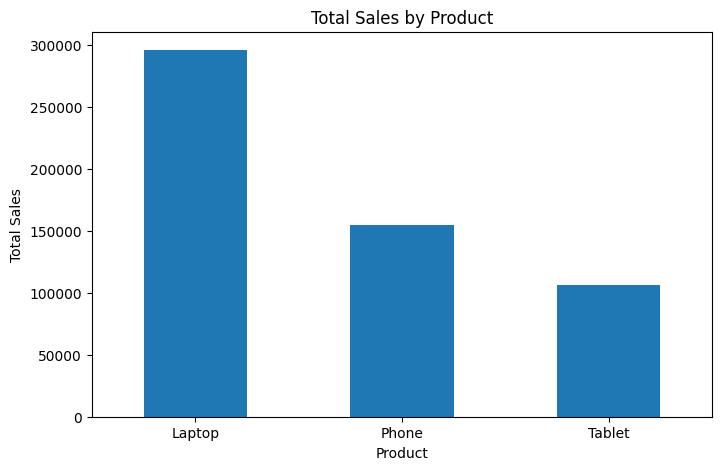

In [ ]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
product_sales.plot(kind="bar")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.title("Total Sales by Product")
plt.xticks(rotation=0)
plt.savefig("visualizations/sales_by_product.png", dpi=300, bbox_inches="tight")
plt.show()

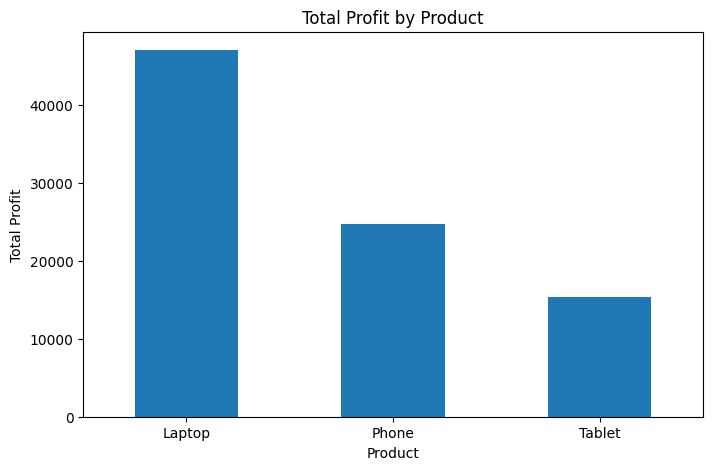

In [ ]:
product_profit = df.groupby("Product")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
product_profit.plot(kind="bar")
plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.title("Total Profit by Product")
plt.xticks(rotation=0)
plt.savefig("visualizations/profit_by_product.png", dpi=300, bbox_inches="tight")
plt.show()

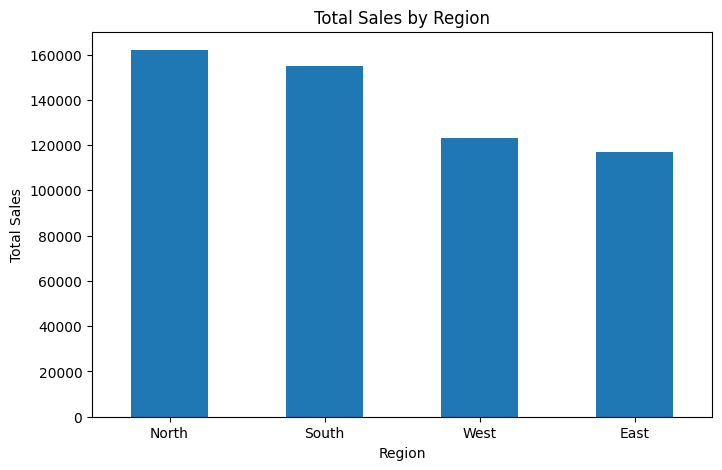

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.title("Total Sales by Region")
plt.xticks(rotation=0)
plt.savefig("visualizations/sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

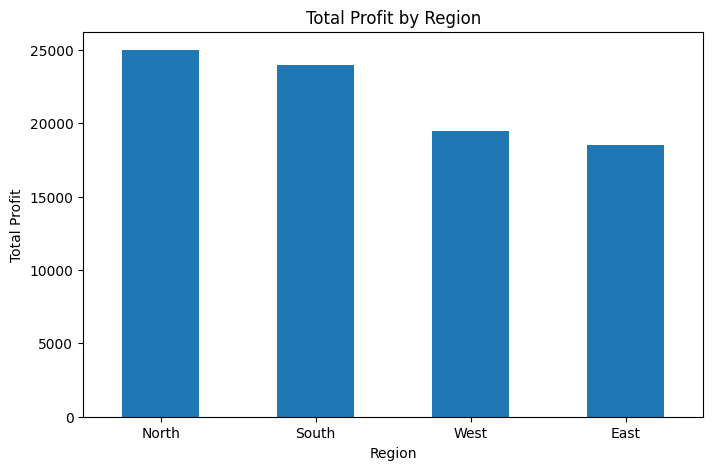

In [ ]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_profit.plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Total Profit by Region")
plt.xticks(rotation=0)
plt.savefig("visualizations/profit_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

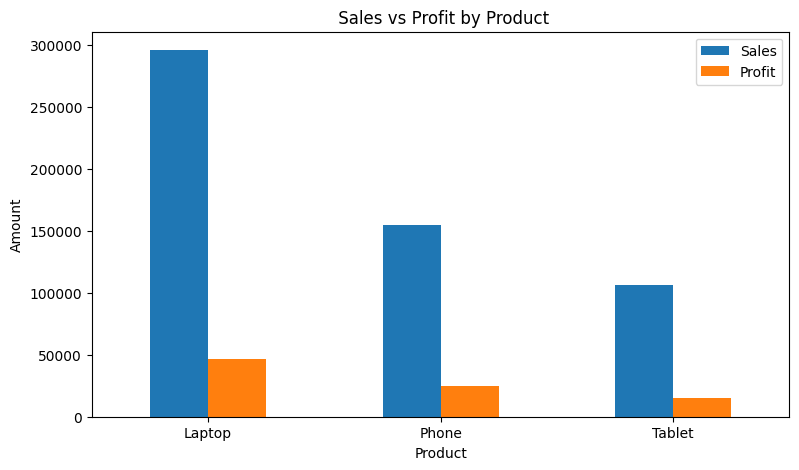

In [ ]:
product_summary = df.groupby("Product")[["Sales", "Profit"]].sum()
product_summary.plot(kind="bar",figsize=(9,5))
plt.xlabel("Product")
plt.ylabel("Amount")
plt.title(" Sales vs Profit by Product")
plt.xticks(rotation=0)
plt.legend(["Sales","Profit"])
plt.savefig("visualizations/sales_vs_profit_by_product.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print("===== KEY FINDINGS =====")

print("\n1. Product with highest sales:")
print(df.groupby("Product")["Sales"].sum().idxmax())

print("\n2. Product with highest profit:")
print(df.groupby("Product")["Profit"].sum().idxmax())

print("\n3. Region with highest sales:")
print(df.groupby("Region")["Sales"].sum().idxmax())

print("\n4. Region with highest profit:")
print(df.groupby("Region")["Profit"].sum().idxmax())

print("\n5. Total sales:")
print(df["Sales"].sum())

print("\n6. Total profit:")
print(df["Profit"].sum())

print("\n7. Average sales:")
print(df["Sales"].mean())

print("\n8. Average profit:")
print(df["Profit"].mean())

===== KEY FINDINGS =====

1. Product with highest sales:
Laptop

2. Product with highest profit:
Laptop

3. Region with highest sales:
North

4. Region with highest profit:
North

5. Total sales:
557000

6. Total profit:
87000

7. Average sales:
55700.0

8. Average profit:
8700.0


# Task 4 - Sentiment Analysis

In [ ]:
reviews = [
    "The product is excellent and I am very happy with it.",
    "Amazing quality and fast delivery.",
    "I really love this product.",
    "The product works perfectly and looks great.",
    "Very good experience, I would buy again.",
    "The quality is okay and the delivery was normal.",
    "The product is average, nothing special.",
    "It is fine for the price.",
    "The product was acceptable.",
    "The quality is poor and I am disappointed.",
    "Very bad product and terrible experience.",
    "The product stopped working after a few days.",
    "I am unhappy with the quality.",
    "The delivery was late and the product was damaged.",
    "Waste of money, I do not recommend it."
]

print("Number of reviews:", len(reviews))

Number of reviews: 15


In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

results = []

for review in reviews:
    score = analyzer.polarity_scores(review)["compound"]

    if score >= 0.05:
        sentiment = "Positive"
    elif score <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    results.append([review, score, sentiment])


In [ ]:
import pandas as pd

In [ ]:
sentiment_df = pd.DataFrame(
    results,
    columns=["Review", "Sentiment Score", "Sentiment"]
)

sentiment_df

,Review,Sentiment Score,Sentiment
0,The product is excellent and I am very happy w...,0.8268,Positive
1,Amazing quality and fast delivery.,0.5859,Positive
2,I really love this product.,0.6697,Positive
3,The product works perfectly and looks great.,0.8519,Positive
4,"Very good experience, I would buy again.",0.4927,Positive
5,The quality is okay and the delivery was normal.,0.2263,Positive
6,"The product is average, nothing special.",-0.3089,Negative
7,It is fine for the price.,0.2023,Positive
8,The product was acceptable.,0.3182,Positive
9,The quality is poor and I am disappointed.,-0.7351,Negative


In [ ]:
sentiment_counts = sentiment_df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    8
Negative    7
Name: count, dtype: int64


In [ ]:
sentiment_percentage = sentiment_df["Sentiment"].value_counts(normalize=True) * 100

print(sentiment_percentage.round(2))

Sentiment
Positive    53.33
Negative    46.67
Name: proportion, dtype: float64


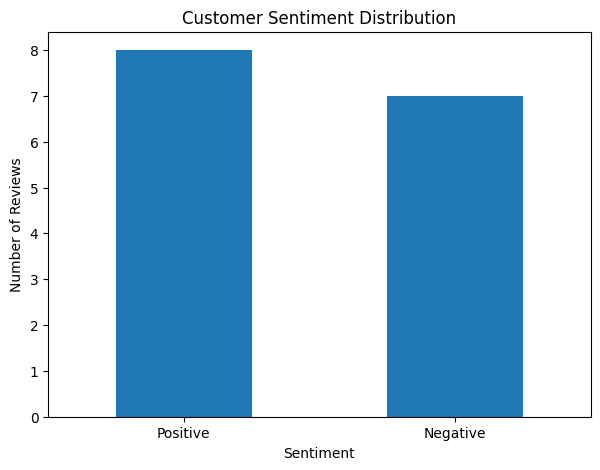

In [43]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))

sentiment_counts.plot(kind="bar")

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.savefig("visualizations/Sentiment Analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
sentiment_counts

,count
Sentiment,
Positive,8
Negative,7


# Sentiment Analysis — Key Findings



*  A total of 15 customer reviews were analysed.
*  8 reviews (53.33%) were classified as positive.

*  7 reviews (46.67%) were classified as negative.

*  No reviews were classified as neutral.
*  Positive reviews were slightly higher than negative reviews.
*  The results show a relatively balanced distribution between positive and negative customer opinions.











# Insights

The sentiment analysis shows that the dataset contains slightly more positive customer feedback than negative feedback. Positive reviews represent 53.33% of the total reviews, while negative reviews represent 46.67%.

Although positive feedback is higher, the relatively small difference between positive and negative reviews suggests that there is room for improvement in customer satisfaction. Businesses can examine the reasons behind negative feedback and use those insights to improve product quality and customer experience.

# Conclusion

Sentiment analysis helped identify the overall tone of customer feedback. Out of 15 reviews, 8 were positive and 7 were negative. The results indicate a slightly positive customer sentiment, but the significant number of negative reviews suggests that further improvements may be needed. Analysing customer feedback can help businesses understand customer opinions and make better decisions.

In [38]:
import os

os.makedirs("visualizations", exist_ok=True)

print("Visualizations folder created successfully!")

Visualizations folder created successfully!


In [40]:
import os
print(os.listdir("visualizations"))

['sales_by_product.png', 'sales_by_region.png', 'profit_by_region.png', 'profit_by_product.png', 'sales_vs_profit_by_product.png']


In [44]:
import os
for file in os.listdir("visualizations"):
    print(file)

sales_by_product.png
sales_by_region.png
Sentiment Analysis.png
profit_by_region.png
profit_by_product.png
sales_vs_profit_by_product.png
